# 02 — Jewish identity trends in the GSS, 1972–2024

The GSS measures Jewishness only through its religion questions, so it sees
"Jews by religion" directly but can only approximate Pew's "Jews of no
religion" category. This notebook tallies, per survey year:

1. **Jewish by religion** — `relig == 'jewish'`
2. **Jewish by religion or upbringing** — `relig == 'jewish'` or
   `relig16 == 'jewish'` (a broader net that recovers *some* Jews of no
   religion, while also sweeping in people who no longer identify as Jewish)
3. Among adults **raised Jewish**, the share now reporting **no religion** —
   the closest GSS proxy for the "Jews of no religion" phenomenon

The point of the exercise is to see **how small the yearly Jewish sample is
and how noisy the resulting estimates are**, so every share is plotted with a
95% confidence interval and a lowess-smoothed trend.

**Methods notes**

- Shares are weighted with `wtssps` (person post-stratification weight, the
  only weight defined for every round including 2021+).
- CIs are Wilson intervals computed on the *effective* sample size
  (Kish: $n_\mathrm{eff} = (\sum w)^2 / \sum w^2$), so they widen to
  reflect unequal weighting.
- GSS skipped some years (1979, 1981, 1992) and went biennial in 1994; the
  2021+ rounds switched from in-person to mostly web administration, which
  NORC warns can shift measured religiosity.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

DATA = os.path.abspath(os.path.join('..', 'data'))
df = pd.read_parquet(os.path.join(DATA, 'derived', 'gss_jewish_identity.parquet'))
print(df.shape, 'years', df.year.min(), '-', df.year.max())

(75699, 8) years 1972 - 2024


In [2]:
def weighted_share(g, num_mask):
    """Weighted share with Wilson 95% CI on the Kish effective sample size."""
    w = g['wtssps'].to_numpy()
    x = num_mask.loc[g.index].to_numpy().astype(float)
    p = (w * x).sum() / w.sum()
    n_eff = w.sum() ** 2 / (w ** 2).sum()
    z = 1.959964
    denom = 1 + z**2 / n_eff
    center = (p + z**2 / (2 * n_eff)) / denom
    half = z * np.sqrt(p * (1 - p) / n_eff + z**2 / (4 * n_eff**2)) / denom
    return pd.Series({'share': p, 'lo': center - half, 'hi': center + half,
                      'n': len(g), 'n_eff': n_eff, 'n_num': int(x.sum())})

# denominator: respondents with a valid current-religion response and a weight
valid = df[df.relig.notna() & df.wtssps.notna()].copy()
valid['jbr'] = valid.relig == 'jewish'                                # Jewish by religion
valid['jbru'] = valid.jbr | (valid.relig16 == 'jewish')               # ... or raised Jewish

jbr = valid.groupby('year').apply(weighted_share, num_mask=valid.jbr, include_groups=False)
jbru = valid.groupby('year').apply(weighted_share, num_mask=valid.jbru, include_groups=False)

# among adults raised Jewish: share now reporting no religion
raised = valid[valid.relig16 == 'jewish'].copy()
raised['now_none'] = raised.relig == 'none'
rj_none = raised.groupby('year').apply(weighted_share, num_mask=raised.now_none, include_groups=False)

summary = pd.concat({'jewish_by_religion': jbr,
                     'jewish_relig_or_raised': jbru,
                     'raised_jewish_now_none': rj_none}, names=['series'])
summary.to_parquet(os.path.join(DATA, 'derived', 'gss_jewish_yearly_summary.parquet'))
jbr[['n', 'n_num', 'share', 'lo', 'hi']].round(4)

,n,n_num,share,lo,hi
year,,,,,
1972,1608.0,54.0,0.0312,0.0231,0.0421
1973,1500.0,42.0,0.0272,0.0195,0.0377
1974,1483.0,44.0,0.0284,0.0204,0.0392
1975,1488.0,23.0,0.0153,0.0098,0.0238
1976,1497.0,27.0,0.0172,0.0113,0.0262
1977,1523.0,35.0,0.0225,0.0156,0.0325
1978,1528.0,29.0,0.0171,0.0106,0.0275
1980,1465.0,32.0,0.0225,0.0149,0.0338
1982,1848.0,38.0,0.0181,0.0117,0.0278


## How small is the yearly Jewish sample?

The table above already shows the problem: a GSS round interviews 1,500–4,000
adults, of whom **`n_num` (a few dozen) are Jewish by religion**. The
summary below makes it explicit.


In [3]:
sizes = pd.DataFrame({
    'total respondents': jbr.n,
    'Jewish by religion': jbr.n_num,
    'Jewish by religion or upbringing': jbru.n_num,
    'raised Jewish': rj_none.n,
}).astype('Int64')  # 1972 is <NA> for raised Jewish: relig16 was first asked in 1973
print(sizes.agg(['min', 'median', 'max']).T.astype(int).to_string())
sizes.T

                                   min  median   max
total respondents                 1367    1812  4484
Jewish by religion                  21      39    78
Jewish by religion or upbringing    26      46   100
raised Jewish                       22      40    86


year,1972,1973,1974,1975,1976,1977,1978,1980,1982,1983,...,2006,2008,2010,2012,2014,2016,2018,2021,2022,2024
total respondents,1608,1500,1483,1488,1497,1523,1528,1465,1848,1595,...,4484,2014,2031,1967,2518,2846,2327,3951,3483,3269
Jewish by religion,54,42,44,23,27,35,29,32,38,43,...,78,39,37,28,40,51,39,76,61,46
Jewish by religion or upbringing,54,48,51,26,35,40,32,37,45,51,...,85,47,41,32,46,64,51,100,74,53
raised Jewish,<NA>,43,49,25,33,37,31,32,44,50,...,55,39,33,28,41,55,42,86,55,47


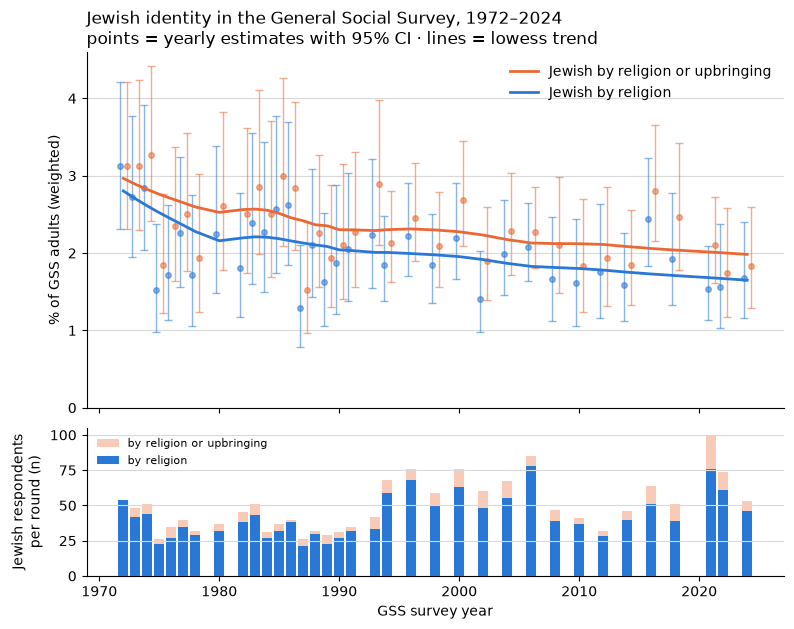

In [4]:
PALETTE = {'jbr': '#2a78d6', 'jbru': '#eb6834', 'none': '#1baf7a'}  # validated slots 1-3
GRID = dict(color='0.85', linewidth=0.8)

def smooth(res, frac=0.4):
    s = lowess(res.share, res.index.to_numpy(), frac=frac)
    return s[:, 0], s[:, 1]

def draw_series(ax, res, color, label, dx=0.0):
    ax.errorbar(res.index + dx, 100 * res.share,
                yerr=[100 * (res.share - res.lo), 100 * (res.hi - res.share)],
                fmt='o', ms=4, color=color, ecolor=color, elinewidth=1,
                capsize=3, alpha=0.55, zorder=2)
    xs, ys = smooth(res)
    ax.plot(xs, 100 * ys, color=color, lw=2, label=label, zorder=3)

fig, (ax, axn) = plt.subplots(2, 1, figsize=(9, 6.8), sharex=True,
                              gridspec_kw={'height_ratios': [2.4, 1], 'hspace': 0.08})

draw_series(ax, jbru, PALETTE['jbru'], 'Jewish by religion or upbringing', dx=+0.28)
draw_series(ax, jbr, PALETTE['jbr'], 'Jewish by religion', dx=-0.28)
ax.set_ylabel('% of GSS adults (weighted)')
ax.set_ylim(0, None)
ax.legend(frameon=False, loc='upper right')
ax.set_title('Jewish identity in the General Social Survey, 1972–2024\n'
             'points = yearly estimates with 95% CI · lines = lowess trend',
             loc='left')
ax.grid(axis='y', **GRID)

axn.bar(jbru.index, jbru.n_num, width=0.85, color=PALETTE['jbru'], alpha=0.35,
        label='by religion or upbringing')
axn.bar(jbr.index, jbr.n_num, width=0.85, color=PALETTE['jbr'],
        label='by religion')
axn.set_ylabel('Jewish respondents\nper round (n)')
axn.set_xlabel('GSS survey year')
axn.legend(frameon=False, fontsize=8, loc='upper left')
axn.grid(axis='y', **GRID)

for a in (ax, axn):
    a.spines[['top', 'right']].set_visible(False)
plt.show()

The top panel shows why single-year GSS estimates of the Jewish population
should be handled with care: the confidence intervals span roughly ±1
percentage point on a ~2% share. The bottom panel is the reason — each round
contains only a few dozen Jewish respondents.


## The closest GSS proxy for "Jews of no religion"

Pew defines *Jews of no religion* as people who report no religion but still
consider themselves Jewish. The GSS never asks the "aside from religion"
follow-up, so the closest available proxy is: **among adults raised Jewish,
the share who now report no religion**. (This misses people raised outside
Judaism who identify as Jewish, and it includes people who no longer identify
as Jewish at all — see notebook 00 for discussion.)


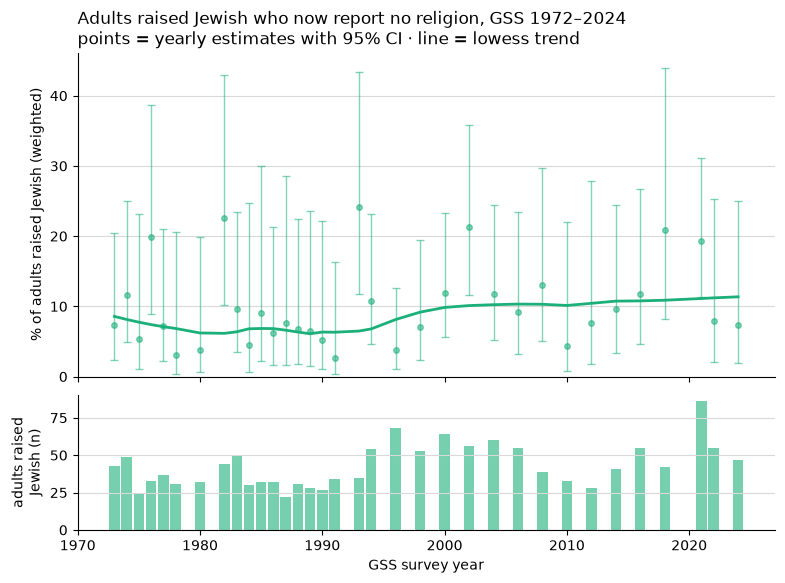

In [5]:
fig, (ax, axn) = plt.subplots(2, 1, figsize=(9, 6.2), sharex=True,
                              gridspec_kw={'height_ratios': [2.4, 1], 'hspace': 0.08})

draw_series(ax, rj_none, PALETTE['none'], 'raised Jewish, now no religion')
ax.set_ylabel('% of adults raised Jewish (weighted)')
ax.set_ylim(0, None)
ax.set_title('Adults raised Jewish who now report no religion, GSS 1972–2024\n'
             'points = yearly estimates with 95% CI · line = lowess trend',
             loc='left')
ax.grid(axis='y', **GRID)

axn.bar(rj_none.index, rj_none.n, width=0.85, color=PALETTE['none'], alpha=0.6)
axn.set_ylabel('adults raised\nJewish (n)')
axn.set_xlabel('GSS survey year')
axn.grid(axis='y', **GRID)

for a in (ax, axn):
    a.spines[['top', 'right']].set_visible(False)
plt.show()

With only 30–90 raised-Jewish adults per round, the yearly points scatter
widely — but the smoothed trend still shows the drift away from religious
identification that Pew documents with purpose-built samples.

## Pooled-decade estimates

Pooling rounds within decades trades time resolution for stability; this is
how GSS-based studies of American Jews (e.g., Tom W. Smith's NORC reports)
actually use the data.


In [6]:
valid['decade'] = valid.year // 10 * 10
raised['decade'] = raised.year // 10 * 10

dec = pd.DataFrame({
    'jewish_by_religion_%': valid.groupby('decade').apply(
        weighted_share, num_mask=valid.jbr, include_groups=False).share * 100,
    'jewish_relig_or_raised_%': valid.groupby('decade').apply(
        weighted_share, num_mask=valid.jbru, include_groups=False).share * 100,
    'raised_jewish_now_none_%': raised.groupby('decade').apply(
        weighted_share, num_mask=raised.now_none, include_groups=False).share * 100,
    'n_jewish': valid.groupby('decade').jbr.sum().astype(int),
    'n_raised_jewish': raised.groupby('decade').size(),
})
dec.round(2)

,jewish_by_religion_%,jewish_relig_or_raised_%,raised_jewish_now_none_%,n_jewish,n_raised_jewish
decade,,,,,
1970,2.28,2.60,9.36,254,218
1980,2.08,2.43,9.15,284,301
1990,2.00,2.30,8.61,269,271
2000,1.91,2.26,12.97,283,274
2010,1.89,2.21,11.78,195,199
2020,1.59,1.90,12.37,183,188
